In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('spam.csv',encoding='latin1')


In [3]:
df.sample(10)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
3732,ham,Old Orchard near univ. How about you?,NaN,NaN,NaN
4931,ham,Match started.india &lt;#&gt; for 2,NaN,NaN,NaN
1114,ham,No no:)this is kallis home ground.amla home to...,NaN,NaN,NaN
5030,ham,Hey... Very inconvenient for your sis a not huh?,NaN,NaN,NaN
4305,ham,Awww dat is sweet! We can think of something t...,NaN,NaN,NaN
4932,ham,Once free call me sir.,NaN,NaN,NaN
3789,ham,I love you !!! You know? Can you feel it? Does...,NaN,NaN,NaN
4234,spam,FREEMSG: Our records indicate you may be entit...,NaN,NaN,NaN
3792,ham,Hey are you angry with me. Reply me dr.,NaN,NaN,NaN
4059,spam,This weeks SavaMob member offers are now acces...,NaN,NaN,NaN


In [7]:
df.shape


(5572, 5)

In [9]:
# data cleaning
# EDA
# text preprocessing
# model building
# evaluation
# improvement
# website
# deploy

# data cleaning

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [9]:
df.drop(columns =['Unnamed: 2','Unnamed: 3','Unnamed: 4'], inplace = True)

In [11]:
# renaming the columns
df.rename(columns ={'v1': 'target','v2':'text'}, inplace = True)

In [13]:
df

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [15]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

In [16]:
df

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [17]:
# missing values
df.isnull().sum()


target    0
text      0
dtype: int64

In [21]:
# check for duplicate values
df.duplicated().sum()

403

In [23]:
# remove duplicate values
df = df.drop_duplicates(keep ='first')

# EDA

In [25]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [27]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

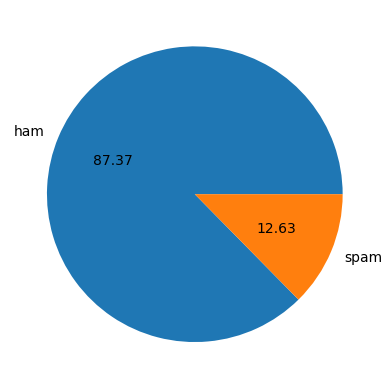

In [29]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels = ['ham','spam'] , autopct = '%0.2f')
plt.show()

# Data is imbalanced

In [31]:
import nltk

In [32]:
df['num_characters'] = df['text'].apply(len) # it will calculate length of all text message

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17284\494597861.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['num_characters'] = df['text'].apply(len) # it will calculate length of all text message


In [35]:
df['num_characters']

0       111
1        29
2       155
3        49
4        61
       ... 
5567    161
5568     37
5569     57
5570    125
5571     26
Name: num_characters, Length: 5169, dtype: int64

In [37]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [39]:
# number of words
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17284\1467726766.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))


In [41]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17284\4112269855.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))


In [43]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [45]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [47]:
# ham
df[df['target']==0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [49]:
# spam
df[df['target']==1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_characters', ylabel='Count'>

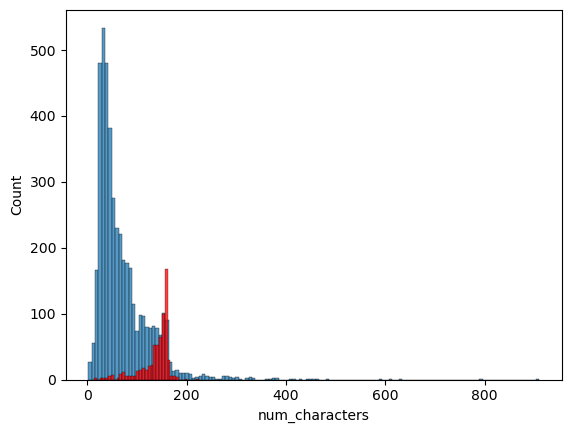

In [51]:
# plot histogrqam
import seaborn as sns
sns.histplot(df[df['target']==0]['num_characters'])
sns.histplot(df[df['target']==1]['num_characters'] , color ='red')

<Figure size 1200x500 with 0 Axes>

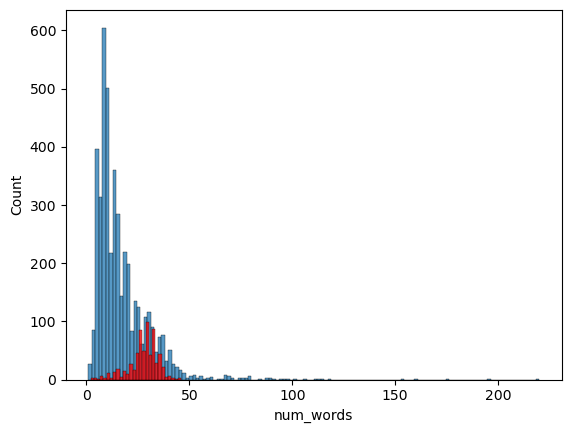

<Figure size 1200x500 with 0 Axes>

In [52]:
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words'] , color ='red')
plt.figure(figsize=(12,5))

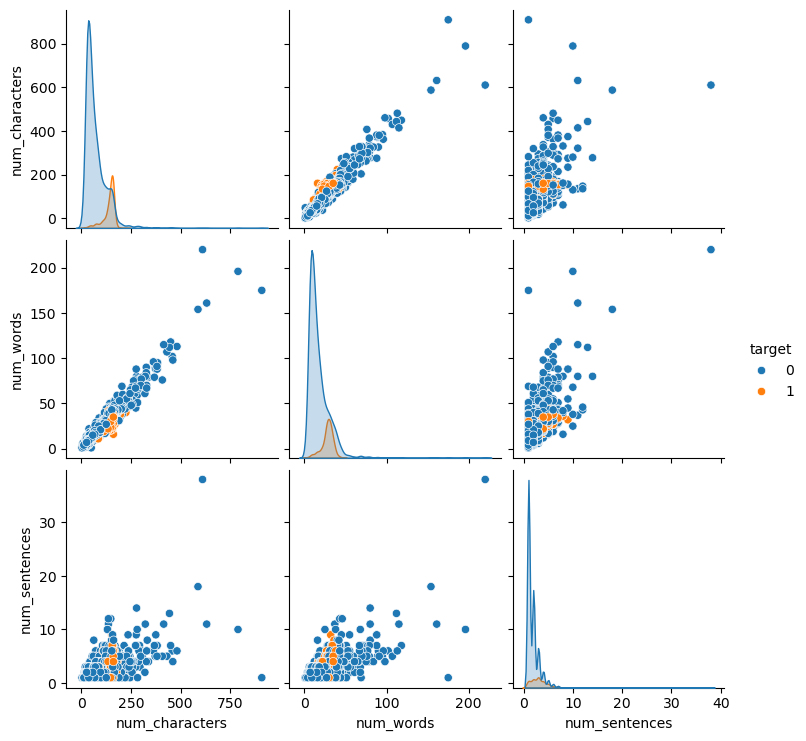

In [55]:
sns.pairplot(df,hue='target')

<Axes: >

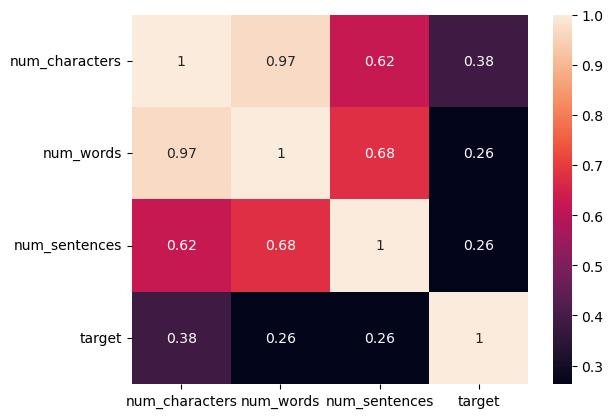

In [57]:
sns.heatmap(df[['num_characters','num_words','num_sentences','target']].corr(),annot=True)

In [59]:
df[['num_characters','num_words','num_sentences','target']].corr()

,num_characters,num_words,num_sentences,target
num_characters,1.000000,0.965760,0.624139,0.384717
num_words,0.965760,1.000000,0.679971,0.262912
num_sentences,0.624139,0.679971,1.000000,0.263939
target,0.384717,0.262912,0.263939,1.000000


# data preprocessing
 

In [50]:
 # lower case
  # tokenization 
  # removing special characters
  # removing stopwords and punctuation
  # stemming

In [61]:
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [63]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [65]:
# stemming
from nltk.stem.porter import PorterStemmer
ps =PorterStemmer()
ps.stem('dancing')

'danc'

In [67]:
def transform_text(text):
    text = text.lower()    # converts all text in lower case
    text = nltk.word_tokenize(text) # tokenize all words

    y = []
    for i in text:
        if i.isalnum():   # removes special character
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text =y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))
    return " ".join(y)

In [69]:
transform_text('hi how are goods you nitish ?')

'hi good nitish'

In [71]:
df['transformed_text']= df['text'].apply(transform_text)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17284\3705489216.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['transformed_text']= df['text'].apply(transform_text)


In [73]:
df

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though
...,...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4,2nd time tri 2 contact u pound prize 2 claim e...
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1,b go esplanad fr home
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2,piti mood suggest
5570,0,The guy did some bitching but I acted like i'd...,125,27,1,guy bitch act like interest buy someth els nex...


In [75]:
from wordcloud import WordCloud
wc = WordCloud(width = 500,height =500, min_font_size =10, background_color = 'white')

In [77]:
# (1 = spam) 
spam_wc = wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))

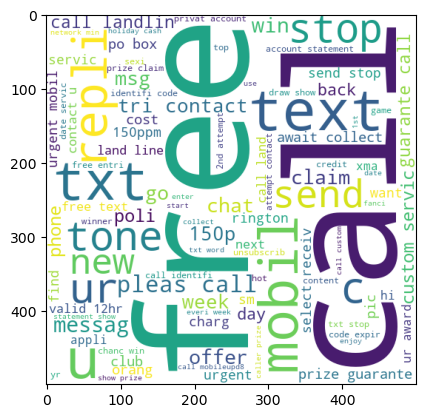

In [79]:
plt.imshow(spam_wc) # spam word cloud

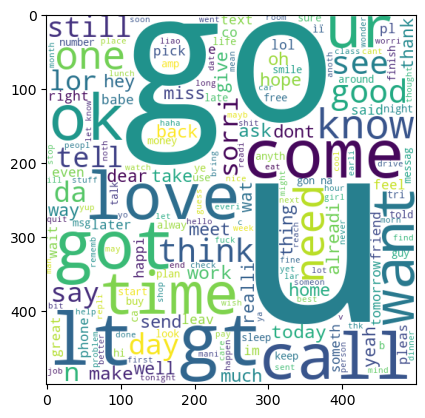

In [81]:
# ham word cloud
ham_wc = wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))
plt.imshow(ham_wc) # Ham word cloud

In [83]:
spam_corpus =[]
for msg in df[df['target']==1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [85]:
len(spam_corpus)

9939

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17284\2017180177.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  sns.barplot(x=0, y=1, data=pd.DataFrame(Counter(spam_corpus).most_common(30))).set_xticklabels(pd.DataFrame(Counter(spam_corpus).most_common(30))[0], rotation=90)


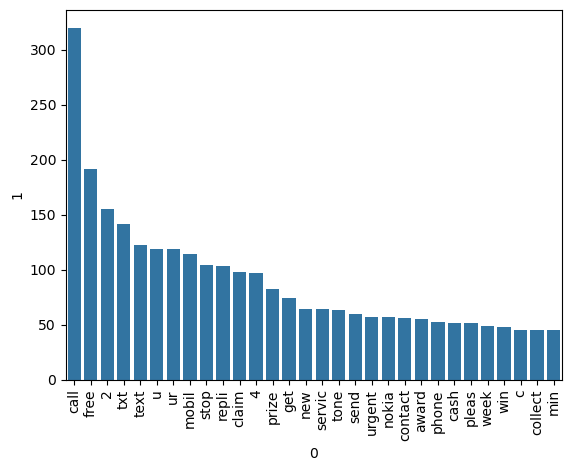

In [108]:
from collections import Counter
sns.barplot(x=0, y=1, data=pd.DataFrame(Counter(spam_corpus).most_common(30))).set_xticklabels(pd.DataFrame(Counter(spam_corpus).most_common(30))[0], rotation=90)
plt.show()


In [100]:
ham_corpus =[]
for msg in df[df['target']==0]['transformed_text'].tolist():
    for word in msg.split():
        
        ham_corpus.append(word)

In [102]:
len(ham_corpus)

35404

<Axes: ylabel='0'>

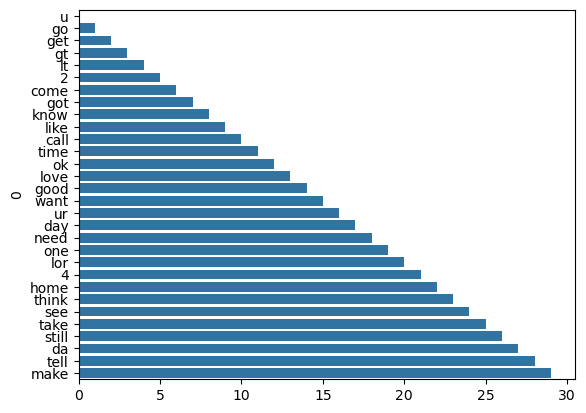

In [ ]:
ham_corpus =[]
for msg in df[df['target']==0]['transformed_text'].tolist():
    for word in msg.split():
        
        ham_corpus.append(word)

# MODEL BUILDING

In [113]:
# TEXT VECTORIZATION
# USING BAG OF WORD

In [199]:
from sklearn.feature_extraction.text import CountVectorizer ,TfidfVectorizer
# cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features =3000)  # it will take top 3000 words

In [121]:
# x = cv.fit_transform(df['transformed_text']).toarray()

In [201]:
X = tfidf.fit_transform(df['transformed_text']).toarray() 

In [203]:
X.shape

(5169, 3000)

In [205]:
y =df['target'].values

In [207]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [209]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 2)

In [211]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [213]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

# we will keep  MultinomialNB

In [215]:
# gnb.fit(x_train,y_train)
# gnb_pred = gnb.predict(x_test)
# print(accuracy_score(gnb_pred,y_test))
# print(confusion_matrix(gnb_pred,y_test))
# print(precision_score(gnb_pred,y_test))

0.8694390715667312
[[788  27]
 [108 111]]
0.8043478260869565


In [217]:
mnb.fit(x_train,y_train)
mnb_pred = mnb.predict(x_test)
print(accuracy_score(mnb_pred,y_test))
print(confusion_matrix(mnb_pred,y_test))
print(precision_score(mnb_pred,y_test))

0.9709864603481625
[[896  30]
 [  0 108]]
0.782608695652174


In [219]:
# bnb.fit(x_train,y_train)
# bnb_pred = mnb.predict(x_test)
# print(accuracy_score(bnb_pred,y_test))
# print(confusion_matrix(bnb_pred,y_test))
# print(precision_score(bnb_pred,y_test))

0.9709864603481625
[[896  30]
 [  0 108]]
0.782608695652174


# improve model

In [ ]:
# tfidf = TfidfVectorizer(max_features =3000)  # it will take top 3000 words

In [223]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))